# Finding enzymes that act on similar substrates to TPHP

In [1]:
import sys
from enzymetk import SubstrateDist
from enzymetk import Save
import pandas as pd
import os

        
data_folder = 'manuscript/'
label = 'ring'
rxn_smiles = 'C1CCCCC1'
id_col = 'id'
output_dir = 'Julia_output/'

reaction_df = pd.read_pickle(os.path.join(data_folder, f'enzymemap_v2_brenda2023_substrates.pkl'))
reaction_df << (SubstrateDist(id_col, 'substrates', rxn_smiles) >> Save(f'{output_dir}substrate_similarity_{label}.pkl'))

Boltz: Needs docko package.Install with: pip install docko. Error: {e}
Chai: Needs docko package. Install with: pip install docko. Error: No module named 'docko'
Vina: Needs docko package. Install with: pip install docko. Error: {e}


/mnt/nfs/vol8t/home/amora/.conda/envs/enzymetk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


EmbedESM3: Needs esm3 package. Install with: pip install esm.


100%|████████████████████████████████████████| 37263/37263 [00:05<00:00, 6480.47it/s]


,id,QuerySmiles,substrates,TanimotoSimilarity,RusselSimilarity,CosineSimilarity
0,['4.4.1.34_297544'],C1CCCCC1,[Br:1][CH2:2][CH:3]1[CH2:4][O:5]1,0.066667,0.000488,0.160128
1,['1.14.12.11_44841'],C1CCCCC1,[Br:1][c:2]1[cH:3][cH:4][c:5]([CH:6]2[CH2:7][C...,0.052632,0.000488,0.140028
2,['5.3.99.7_306933'],C1CCCCC1,[Br:1][c:2]1[cH:3][cH:4][c:5]([CH:6]2[CH2:7][O...,0.047619,0.000488,0.132453
3,['4.2.1.20_288678'],C1CCCCC1,[Br:1][c:2]1[cH:3][cH:4][c:5]2[cH:6][cH:7][nH:...,0.043478,0.000488,0.125988
4,['4.3.3.5_296189'],C1CCCCC1,[Br:1][c:2]1[cH:3][cH:4][c:5]2[nH:6][c:7]3[c:8...,0.000000,0.000000,0.000000
...,...,...,...,...,...,...
37258,['1.14.12.12_44981'],C1CCCCC1,[cH:95]1[cH:96][cH:97][c:98]2[cH:99][c:100]3[c...,0.000000,0.000000,0.000000
37259,['4.2.1.122_287554'],C1CCCCC1,[cH:9]1[cH:10][cH:11][c:12](-[c:13]2[cH:14][cH...,0.000000,0.000000,0.000000
37260,"['1.2.7.5_71763', '1.2.7.5_71799']",C1CCCCC1,[cH:9]1[cH:10][cH:11][c:12]([CH2:13][n+:14]2[c...,0.000000,0.000000,0.000000
37261,"['4.2.1.20_288604', '4.2.1.122_287548']",C1CCCCC1,[cH:9]1[cH:10][cH:11][c:12]2[nH:13][cH:14][cH:...,0.052632,0.000488,0.140028


# Get the most similar substrates now

In [2]:
# Get the distance df 
# Get the top 20 reactions
import pandas as pd
from ast import literal_eval
import numpy as np
import os

n = 20

substrate_distance_df = pd.read_pickle(f'{output_dir}substrate_similarity_{label}.pkl')
top_substrate_distance_df = substrate_distance_df.sort_values(by='TanimotoSimilarity', ascending=False).head(n)
top_substrate_distance_df['substrates'].values

array(['[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5][CH2:6][CH2:7][CH2:8]1',
       '[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5][CH2:6]1',
       '[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5]1',
       '[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5][CH2:6][CH2:7]1',
       '[CH2:1]1[CH2:2][CH2:3][NH:4][CH2:5][CH2:6]1',
       '[CH2:1]1[CH2:2][CH2:3][O:4][CH2:5][CH2:6]1',
       '[CH2:1]1[CH2:2][CH2:3][S:4][CH2:5][CH2:6]1',
       '[O:45]=[C:46]1[CH2:47][CH2:48][CH2:49][CH2:50][CH2:51][CH2:52][CH2:53]1',
       '[OH:52][CH:53]1[CH2:54][CH2:55][CH2:56][CH2:57][CH2:58]1',
       '[OH:89][CH:90]1[CH2:91][CH2:92][CH2:93][CH2:94][CH2:95][CH:96]1[OH:97]',
       '[O:49]=[C:50]1[CH2:51][CH2:52][CH2:53][CH2:54][CH2:55][CH2:56][CH2:57][CH2:58][CH2:59]1',
       '[O:49]=[C:50]1[CH2:51][CH2:52][CH2:53][CH2:54][CH2:55][CH2:56][CH2:57]1',
       '[O:11]=[C:12]1[CH2:13][CH2:14][CH2:15][CH2:16][CH2:17]1',
       '[O:49]=[C:50]1[CH2:51][CH2:52][CH2:53][CH2:54][CH2:55]1',
       '[OH:15][CH:16]1[CH2:17][CH2:18][CH2:19][CH2:20][CH2:21]1

# Check what enzymes these connect to 

In [3]:
top_substrate_distance_df

,id,QuerySmiles,substrates,TanimotoSimilarity,RusselSimilarity,CosineSimilarity
23,"['1.14.15.3_53256', '1.14.15.3_53257']",C1CCCCC1,[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5][CH2:6][CH...,1.000000,0.001465,1.000000
21,"['1.11.2.1_37965', '1.14.13.25_47084', '1.14.1...",C1CCCCC1,[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5][CH2:6]1,1.000000,0.001465,1.000000
20,"['4.1.2.13_281818', '1.14.15.3_53258', '1.14.1...",C1CCCCC1,[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5]1,1.000000,0.001465,1.000000
22,"['1.14.15.3_53252', '1.14.15.3_53253']",C1CCCCC1,[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5][CH2:6][CH...,1.000000,0.001465,1.000000
29,['2.3.1.145_111261'],C1CCCCC1,[CH2:1]1[CH2:2][CH2:3][NH:4][CH2:5][CH2:6]1,0.333333,0.001465,0.577350
31,['1.11.2.1_38011'],C1CCCCC1,[CH2:1]1[CH2:2][CH2:3][O:4][CH2:5][CH2:6]1,0.333333,0.001465,0.577350
33,['2.1.1.96_106922'],C1CCCCC1,[CH2:1]1[CH2:2][CH2:3][S:4][CH2:5][CH2:6]1,0.333333,0.001465,0.577350
31921,"['1.1.1.245_11981', '1.1.1.1_1601']",C1CCCCC1,[O:45]=[C:46]1[CH2:47][CH2:48][CH2:49][CH2:50]...,0.272727,0.001465,0.522233
36698,['2.3.1.69_121416'],C1CCCCC1,[OH:52][CH:53]1[CH2:54][CH2:55][CH2:56][CH2:57...,0.272727,0.001465,0.522233
36973,['1.1.1.245_11931'],C1CCCCC1,[OH:89][CH:90]1[CH2:91][CH2:92][CH2:93][CH2:94...,0.272727,0.001465,0.522233


In [4]:

data_folder = 'manuscript/'

# Read in the embedded datasets and each of the processed datasets from CARE (we expect you to just download the task1 datasets and put them in processed datasets)
protein_encoding_df = pd.read_pickle(os.path.join(data_folder, 'protein.pkl'))

# Read in the reaction df 
reaction_df = pd.read_pickle(os.path.join(data_folder, 'enzymemap_v2_brenda2023_reactions.pkl'))
products_df = pd.read_pickle(os.path.join(data_folder, 'enzymemap_v2_brenda2023_products.pkl'))
substrates_df = pd.read_pickle(os.path.join(data_folder, 'enzymemap_v2_brenda2023_substrates.pkl'))

# Now convert to dictionaries to map between 
ec_grps = reaction_df.groupby('ec_num')['unmapped'].apply(list).reset_index(name='reaction_unmapped')
ec_to_reaction = dict(zip(ec_grps['ec_num'].values, ec_grps['reaction_unmapped'].values))

# Ensure that the substrates are read in as a list.
reaction_df.substrates = reaction_df.substrates.apply(literal_eval)
reaction_df.products = reaction_df.products.apply(literal_eval)

reaction_to_substrates = dict(zip(reaction_df['unmapped'].values, reaction_df['substrates'].values))
reaction_to_products = dict(zip(reaction_df['unmapped'].values, reaction_df['products'].values))

from tqdm import tqdm

ec_dict = ec_to_reaction
rows = []
substrate_rows = []
for entry, seq, ecs in tqdm(protein_encoding_df[['Entry', 'Sequence', 'EC number']].values):
    ecs = ecs.split('|')
    count_pos = 0
    for ec in ecs:
        if ec_dict.get(ec):
            reactions = ec_dict.get(ec)
            for reaction in reactions:
                rows.append([entry, ec, reaction])
                substrates = reaction_to_substrates.get(reaction)
                for s in substrates:
                    substrate_rows.append([entry, ec, s])
df = pd.DataFrame(rows, columns=['Entry', 'EC number', 'Reaction'])
s_df = pd.DataFrame(substrate_rows, columns=['Entry', 'EC number', 'Substrate'])

# Get the top ones
top_substrates = top_substrate_distance_df['substrates'].values
top_df = s_df[s_df['Substrate'].isin(top_substrates)]


100%|█████████████████████████████████████| 261254/261254 [00:07<00:00, 36245.15it/s]


In [5]:
top_df

,Entry,EC number,Substrate
14719,A5JYX5,1.1.1.1,[O:45]=[C:46]1[CH2:47][CH2:48][CH2:49][CH2:50]...
17348,A8B2U2,4.1.2.13,[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5]1
23691,B9W4V6,1.11.2.1,[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5][CH2:6]1
23901,B9W4V6,1.11.2.1,[CH2:1]1[CH2:2][CH2:3][O:4][CH2:5][CH2:6]1
30563,D4GYE0,4.1.2.13,[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5]1
...,...,...,...
5576464,Q9U8S9,1.1.1.1,[O:45]=[C:46]1[CH2:47][CH2:48][CH2:49][CH2:50]...
5579074,Q9V2I6,4.1.2.13,[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5]1
5581010,Q9XB14,3.8.1.5,[Cl:1][CH:2]1[CH2:3][CH2:4][CH2:5][CH2:6][CH2:7]1
5582841,Q9YG90,4.1.2.13,[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5]1


In [6]:
top_df['EC number'].value_counts()

EC number
1.1.1.1       191
4.1.2.13      168
3.1.1.3       139
3.4.23.1       84
1.14.15.3      56
3.8.1.5        33
1.14.13.25     16
1.1.1.2        15
1.1.1.245       6
1.1.1.184       6
1.1.1.53        4
1.14.13.22      3
1.11.2.1        2
1.1.1.188       2
1.14.13.16      2
2.8.2.22        2
2.8.2.3         2
1.14.13.92      1
3.4.22.6        1
2.3.1.145       1
Name: count, dtype: int64

# Check what the substrates look like

In [7]:
! pip install pubchempy

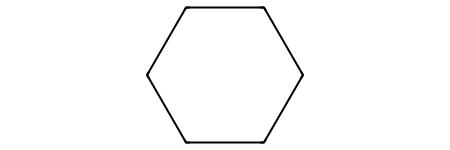

In [8]:
from rdkit import Chem
from rdkit.Chem import Draw
import pubchempy

m2 = Chem.MolFromSmiles(rxn_smiles)
m2

[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5][CH2:6][CH2:7]1
Compounds [Compound(9265)]
[O:89]=[C:90]1[CH2:91][CH2:92][CH2:93][CH2:94][CH2:95][C:96]1=[O:97]
Compounds [Compound(76365)]
[O:45]=[C:46]1[CH2:47][CH2:48][CH2:49][CH2:50][CH2:51][CH2:52][CH2:53]1
Compounds [Compound(10403)]
[O:49]=[C:50]1[CH2:51][CH2:52][CH2:53][CH2:54][CH2:55]1
Compounds [Compound(7967)]
[CH2:1]1[CH2:2][CH2:3][NH:4][CH2:5][CH2:6]1
Compounds [Compound(8082)]
[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5]1
Compounds [Compound(9253)]
[O:1]=[C:2]1[CH2:3][CH2:4][CH2:5][CH2:6][CH2:7]1
Compounds [Compound(7967)]
[CH2:1]1[CH2:2][CH2:3][CH2:4][CH2:5][CH2:6][CH2:7][CH2:8]1
Compounds [Compound(9266)]
[OH:15][CH:16]1[CH2:17][CH2:18][CH2:19][CH2:20][CH2:21]1
Compounds [Compound(7966)]
[O:49]=[C:50]1[CH2:51][CH2:52][CH2:53][CH2:54][CH2:55][CH2:56][CH2:57][CH2:58][CH2:59]1
Compounds [Compound(73918)]
[CH2:1]1[CH2:2][CH2:3][O:4][CH2:5][CH2:6]1
Compounds [Compound(8894)]
[OH:13][CH:14]1[CH2:15][CH2:16][CH2:17][CH2:18][CH2:19]1
Compounds [Compo

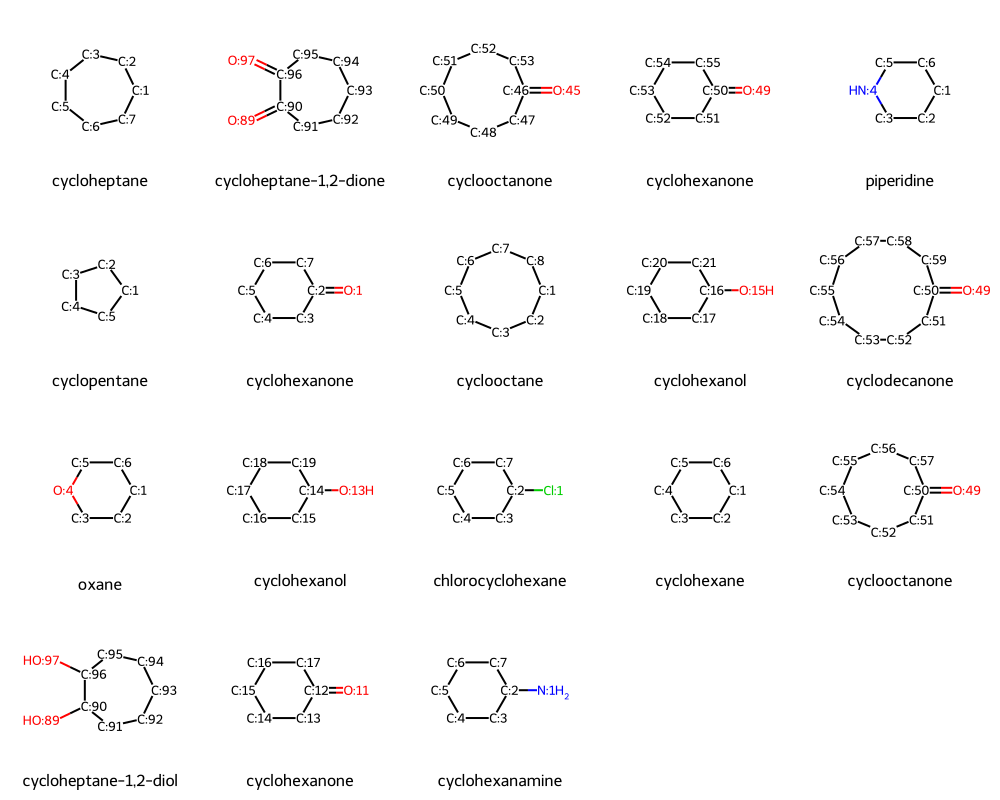

In [10]:


names = []
smiles_to_name = {}
ms = []
count = 5
for c in set(top_df['Substrate'].values):
    print(c)
    mol = Chem.MolFromSmiles(c)
    ms.append(mol)
    compounds = pubchempy.get_compounds(c, namespace='smiles')
    print("Compounds", compounds)
    if compounds[0].iupac_name:
        smiles_to_name[c] = compounds[0].iupac_name
        names.append(compounds[0].iupac_name)
    else:
        names.append("Not found name")
        smiles_to_name[c] = "Not found name"

# plot them all as an image
img=Draw.MolsToGridImage(ms, molsPerRow=5, subImgSize=(200,200) ,legends=names)    
img

# Add information e.g. about the organism 

In [ ]:
from sciutil import SciUtil

length_filter = 300

u = SciUtil()

protein_info = pd.read_csv(f'{data_folder}uniprotkb_reviewed_true_2025_17_02.tsv', sep='\t')
# Filter for "short" bacterial sequences
proteins = protein_encoding_df[protein_encoding_df['Entry'].isin(top_df['Entry'].values)]

proteins = proteins[proteins['Length'] < length_filter]

# Finally select those that come from bacteria for obvious reasons...
protein_all_info = protein_info[protein_info['Entry'].isin(proteins['Entry'].values)]
# 2157 or 2 (archaea or bacteria)
protein_all_info['superkingdom'] = [c.split(',')[1].split(' ')[1].strip() for c in protein_all_info['Taxonomic lineage (Ids)'].values]

u.dp(['Superkingdom'])
print(protein_all_info['superkingdom'].value_counts())
protein_all_info = protein_all_info[protein_all_info['superkingdom'].isin(['2', '2157'])]

# Add in if you want to remove cofactors
# u.dp(['Cofactors'])
# print(protein_all_info['Cofactor'].value_counts())
# protein_all_info = protein_all_info[protein_all_info['Cofactor'].isna()]

u.dp(['Subunits'])
print(protein_all_info['Subunit structure'].value_counts())
protein_all_info['Subunit'] = ['Monomer or Homodimer' if (isinstance(s, (int, float, complex)) or 'Monomer' in s or 'Homodimer' in s) else 'Complex' for s in protein_all_info['Subunit structure'].values]
protein_all_info = protein_all_info[protein_all_info['Subunit'] == 'Monomer or Homodimer']

protein_all_info.to_csv(os.path.join(output_dir, f'{label}_enzymes_based_on_substrates.csv'), index=False)
protein_all_info

# Now print out the most similar reactions again

In [ ]:
top_df = top_df[top_df['Entry'].isin(protein_all_info['Entry'].values)]

names = []
smiles_to_name = {}
ms = []
for c in set(top_df['Substrate'].values):
    print(c)
    mol = Chem.MolFromSmiles(c)
    ms.append(mol)
    compounds = pubchempy.get_compounds(c, namespace='smiles')
    print("Compounds", compounds)
    if compounds[0].iupac_name:
        smiles_to_name[c] = compounds[0].iupac_name
        names.append(compounds[0].iupac_name)
    else:
        names.append("Not found name")
        smiles_to_name[c] = "Not found name"
# plot them all as an image
img = Draw.MolsToGridImage(ms, molsPerRow=5, subImgSize=(200,200),legends=names)    
img

# Since we have many sequences, we're going to reduce this down to ~15 like the other two proteins to make it more fair

To do this, we just cluster the sequences using mmseqs2 (90% identity)

In [ ]:
from enzymetk.similarity_mmseqs_step import MMseqs
from enzymetk.save_step import Save
import pandas as pd

id_col = 'Entry'
seq_col = 'Sequence'
protein_all_info << (MMseqs(id_col, seq_col, method='cluster', args=['--min-seq-id', '0.8', '-c', '0.8', '--cov-mode', '0']) >> Save(f'{output_dir}{label}_mmseqs_files.pkl'))


In [ ]:
clustered_seqs = pd.read_pickle(f'{output_dir}{label}_mmseqs_files.pkl')
len(clustered_seqs['mmseqs_representative_cluster_seq'].value_counts())

In [ ]:
clustered_seqs['mmseqs_representative_cluster_seq'].value_counts()

# We'll order the cluster centers 

In [ ]:
cluster_centres = set(clustered_seqs['mmseqs_representative_cluster_seq'].value_counts().index)
protein_all_info = protein_all_info[protein_all_info['Entry'].isin(cluster_centres)]
protein_all_info

# Codon optimize the sequences 

I use IDT codon optimization since I'll be ordeirng through them: https://www.idtdna.com/pages/tools/codon-optimization-tool


![Screenshot 2025-03-26 at 2.49.01 PM.png](attachment:f700103f-be36-4012-a103-f22de7019614.png)

In [ ]:
for entry, seq in protein_all_info[['Entry', 'Sequence']].values:
    print(f'>{entry}\n{seq}')

In [ ]:
optimized = {'O35016': 'ATGATCTCTGTTTTATTCGTATGCCTGGGAAACATCTGTCGTAGTCCTATGGCGGAAGCGATTTTCCGTGATCTTGCAGCCAAGAAAGGCTTGGAGGGTAAAATCAAGGCGGACTCCGCCGGGATTGGGGGATGGCATATTGGAAATCCTCCACATGAGGGGACACAAGAAATCTTACGTCGCGAAGGTATTAGCTTTGATGGTATGTTGGCCCGCCAGGTCAGCGAACAGGATCTTGACGATTTCGACTACATTATTGCGATGGATGCGGAGAATATTGGCTCGCTTCGTTCTATGGCGGGATTCAAAAACACCAGTCATATCAAGCGTTTACTGGACTATGTCGAAGATAGTGACCTTGCGGACGTGCCGGACCCCTATTATACTGGTAATTTTGAAGAGGTTTGCCAGTTAATCAAGACAGGCTGTGAGCAATTGCTTGCAAGTATCCAGAAAGAGAAGCAATTG', 
             'O52787': 'ATGCAGTTCAAGAACATCCTTGTTGTGTGCATCGGTAACATCTGCCGTAGCCCTATGGCCGAGTACCTTCTGAAACAAAATTATCCTCAACTTACAATTCATTCGGCTGGGATCAGTGGCATGATCGGATACTCTGCTGACGAGAAAGCGCAATTGTGCATGGAACGCATTGGGATTGATATGTCGCCCCATATTGCTAAAAAATTAAACGCTGAACTTCTGAAACAGGCTGATTTAATTCTGGTGATGTCGCAGAACCAACAAAAGCACATCGAGCAAACGTGGCCTTTCGCCAAAGGGAAGACTTTTCGCTTAGGACACTGGCAAGGCAAAAACATCCCCGATCCATATCAACACGATCAGGCGTTTTTTGACGAGACGAGTCTTCTGATTCAAACTTGCGTCGCCGACTGGACAAAGCATATC', 
             'P0C5D3': 'ATGAAAATCCTTTTTGTGTGTACAGGAAATACATGTCGTTCCCCATTGGCCGAATCTATCGCTAAAGAAGTAATGCCAAATCATCAATTCGAGTCGCGTGGGATCTTCGCTGTGAATAACCAAGGAGTTAGCAACTATGTTGAGGATTTAGTGGAGGAGCACCATCTGGCGGAAACAACGTTGTCACAGCAGTTCACTGAAGCTGATCTTAAGGCGGACATCATTCTGACCATGTCGTACTCGCACAAAGAATTGATCGAGGCGCACTTCGGGCTTCAGAACCACGTGTTTACGCTGCACGAATACGTTAAAGAGGCTGGCGAAGTGATCGACCCCTACGGCGGTACTAAAGAAATGTACGTGCACACCTACGAAGAACTTGTCTCCCTGATCCTTAAATTAAAAGACATTATTTGT', 
             'P39852': 'ATGGTGGATATTCATAATCACATCTTGGTAGACGTTGACGATGGTCCCAAATCAATCAATGAAGCCATTGAATTGTTAAAACAGGCCCAGAGCGAAAATGTGACCGATATCGTAGCGACTCCACACCATCTGCACAAACGTTATAGTAATGACATCGAAAAGGTGAAGATCAAGCTTAACGAGTTGAAAAATAATTCAGAGATCAAAAAATTAGGCTTAAACCTGTACGTAGGCCAAGAAATCCGCATCACTGATCAGATTATCGAAGGCATTAAGAACAAAGAGATCGAAGGGATTAACGAGTCTCGCTACTTACTTATTGAGTTCCCAAGCAATGAGATTCCTTACTACACTAACCAGCTGTTCTACGAATTGCAAACAATGGGATATATTCCGATCATCGCTCACCCGGAACGCAACAAAGCTATCGTCCAAAATTTGGACTTGCTTTTTGAGTTAATCAACGGAGGCGCTCTTTCCCAAATTACCGCTTCATCCCTTTTAGGTGACTTCGGGAATAACATTCGCAAGCTGAGCCTTAAGATGATCGACAGCAACTTGGCGCATTTTATCGCGAGCGATGCACATTCTATCACCAACCGTCCTTTCATGCTGAAACAGTTATTCAATGACCGCAAGCTTAAAGCTTACTATGAGGAGCTGGAGTCCTATCTTAAGAATGGTAAACTGGTCCTTACCAATGAACGTATCTCAAAACAAATTCCTACTCAAGATTACAAACAGAAAAAGTGGTTTGGCCTGCTT', 
             'Q05918': 'ATGAAAACTCATCATGCAAACCTGGCGCTGGCTCTGATGTTGGGACTGTCTAGCAGTGCCACAGCGGTCGCGGCCGACGCGCCACAAGCGGTAGCAACAAAGGCCGCGGCCCCAAACGTAAAACCTGTCGCTGCGGATGCACATGGTGTCATCCCCGACGGAGCTCCAGGTATGTGTGCCCGCAGTCCTGCTTGCCGCGCCACCGCCATCCCCGCGGACGCATTTGTCCGCACAGCTGATCTGGGCCGCCTTACGGATGCTGATCGTGACGCTCTTGCTGCTTTAGGAGTAAAGTTGGACATCGACTTGCGTACAGCAGATGAGGAAGCCCAGTCACCAGACTTATTAGCCCGTGACGACCGCTTTGACTACCAACGTATTTCTTTAATGGGAACTGAAAAAATGGACTTGCAGAAGATGATGACATCCTTTCCAGATTCGCTTGGAGAAGCGTATGTGCAATGGTTGGGGCACAGCCAACCTCAGTTCAAACAAGTTTTTCAGCGTATCGCAGCGCAACAAGACGGTGCCGTTCTGTTTCACTGCACCGCGGGAAAAGACCGTACTGGTATCATCGCGGGGTTATTGTTAGATTTAGCGGGTGTCCCTAAGGCCGAAATCGTGCACAATTATGCAATCTCTGCGCACTATTTAGAGGGACAACCAAAGGATTCGGACGAGCGTGCAGATCATGGGGCTGGCCAGGCGGAGCCTGGGGACCGCCCACAAGACGGCGGGCATGGTCGTTATCGCGCTGGACAACACGGAGCTGTTTTGGCAGCCTTACATTCACAATATGGGGGAGCAGAAGGGTACTTGAAATCAATTGGGGTTTCCGAACAAGAAATCCAGCAATTAAAAGTACGCTTAGGCCAAGCTGGT', 
             'Q92G53': 'ATGAAGCGTAAGAACAACAAATTCATCGAGATTTCTATTGCGTTCATTCTGGGGATCGCATTAGGGTTGTACGGTCAAAATCCTGACTACTTCACCAACCTGATCAGCCAAAAAAGCTTGGCGTTAAGCGCTTTGCAAATTAAGCATTACAACATCTCGGAATTATCCCGCTCTAAAGTCTCGACCTGCTTTACCCCCCCTGCCGGATGTACGAAGTTCATCGCCAACCAAATCGATAAGGCCGAAGAGAGCATTTACATGCAGGCTTACGGGATGAGCGATGCCCTGATTACAACAGCATTGATCAATGCACAGGCACGCGGTGTCAAAGTACGCATCCTTCTGGATCGCAGCAACCTGAAACAGAAATTCTCCAAGTTGCATGAGTTACAACGCGCTAAAATTGATGTGGATATCGATAAGGTCCCTGGAATCGCACATAACAAAGTGATCATCATCGACAAGAAAAAGGTAATCACTGGCTCTTTCAACTTTACAGCCGCGGCTGACAAGCGTAACGCTGAGAACGTAATCATTATTGAAGACCAGGAGTTGGCTGAATCGTACTTGCAAAACTGGCTTAACCGTAAAGCCTCGAAT', 
             'Q9FAW5': 'ATGAAATTGGTCGTAATTAATGGCACCCCGCGTAAATTCGGCCGCACACGTGTAGTAGCAAAATACATTGCAGATCAATTTGAAGGCGAGCTGTATGATTTAGCTATTGAGGAGCTTCCCTTATATAATGGTGAGGAAAGTCAGCGCGATTTGGAAGCCGTCAAGAAACTGAAGACGTTAGTGAAGGCGGCCGATGGTGTAGTTTTATGCACCCCCGAGTATCATAATGCAATGTCCGGAGCGCTTAAAAATTCCTTGGACTATCTTAGTTCCTCCGAGTTCATCCACAAACCTGTGGCCTTGCTGGCGGTAGCTGGGGGAGGTAAAGGAGGAATTAACGCATTAAACAGTATGCACGCCTCTTTAGCCGGAGTTTATGCCAACGCCATTCCCAAACAAGTCGTGCTTGACGGCCTGCATGTGCAGGATGGTGAGTTAGGGGAGGATGCCAAACCCCTTATCCACGATGTCGTTAAGGAGTTAAAAGCGTATATGTCAGTCTATAAGGAAGTCAAAAAACAGTTAGGTGTTGAA', 
             'P26975': 'ATGAAGAAACTTCTTGCAGTCTTTTGCGCAGGTGCATTTGTTTCTACTTCCGTGTTTGCGGCCATCCCGCCCGGAAACGACGTTACAACTAAACCAGACCTGTACTATCTTAAGAACAGCCAAGCTATTGATTCGCTTGCGCTGCTGCCGCCTCCACCTGAGGTGGGTTCCATTTTATTCCTTAACGATCAAGCGATGTACGAAAAGGGTCGTCTGCTTCGCAACACTGAGCGTGGAGAGCAGGCTGCGAAGGATGCTGATCTTGCTGCGGGTGGGGTTGCAAACGCATTCTCGGAAGCCTTTGGATATCCCATCACCGAGAAAGACGCCCCTGAAATCCACAAACTTCTTACGAATATGATCGAGGATGCAGGGGACTTGGCCACCCGCTCCGCAAAAGAAAAGTACATGCGCATTCGCCCGTTTGCGTTCTACGGTGTGGCTACGTGCAATACGAAGGATCAGGATAAATTGTCCAAGAACGGTTCTTATCCTTCTGGACATACAGCAATTGGATGGGCATCGGCTCTTGTATTGAGTGAGATCAACCCCGAGAATCAAGATAAGATCTTAAAGCGCGGATACGAGCTGGGGCAGTCGCGTGTGATCTGTGGGTATCATTGGCAATCTGATGTTGACGCCGCTCGCATTGTAGCATCCGGGGCGGTGGCCACGTTGCATAGTAATCCAGAGTTCCAAAAGCAATTGCAGAAAGCGAAGGATGAGTTCGCGAAGCTGAAGAAA', 
             'P40289': 'ATGATCAAATGGTTACAGCGCGCAGGGTGTTTGAGTGCACATGCGGTGGTACCGCAGGCCCCGGCCGCTGCGTCCGTTCAAGGTCGCCACGACCTTGCGTTCGATACAATTTCAAATGCTCGTGATCTTGGTGGACTGGCTGGTGCTGGTGGACGCCGTGTACGTCAAGGGCGTTTATACCGCTCGGGTAACCCTGCATTAGCTAGTGCGGCAGACTTAGAGCGTTTGCAGACGTTGGGGTTGGATATGGTAGTGGATTTTCGCTCCCCAGGCGAAAAAAGCCCTGAGGAGGCTGCGTTCGGGCAACGTTTCCACTGGGTAGCGGCGCCGGTTTTGGAAGGAAGCATGGCAATGGATGTGTTAATGCCCCGCCTGCGCGCCTCAACGCCCGCTCAAATGGACGCTTTCATGCTTGAGGTGTATGGCGATTTCCCGGTCCGCTACCGTGAAGCTTTTGCAGGCTTCATGCGCACAGCACAAGGAGGAAAGACGTTACTTTTTCACTGTACGGCAGGGAAGGATCGTACCGGGTTTGCTGCCCTTCTTTTACTGGCTGCCCTTGGCGTAGCGCAAGACGATATTTTAGCTAATTACTTAGAATCGAACCAACGTAATGCGCAATTCAATCAAACCGCGCTTGCGCGTATGGCGGGTTTAGGGGTAGCCCCCGCAGTAATGACTCCTTTGCTTGAGGTACGTGCATCGTACCTTGACGCCTCTATGCGCGCCATTGATGCCGGGTGGGGATCTGTCGATAATTATTTACGTGACGCCTTGGAGGTCGATGTAGCACAACTGCGCGGTCACTATCTTGCGGGG', 
             'P49409': 'ATGGCTCCGCGCAGTCTGTTTTTACAGCGTTTCCAACCCCGCGACCTTACAAAAGCTTGGAACCAGTTAAACCTGTTTGACGAAATTCAATTCGCGTTCCTTATTTACTCTCAAGTGTATTCTAAGACCTTAATGGATTTTCAAAAGCGTTGGGCGCAGGGAGTCCTGGACCTGGAGGAGAACGCTCCGCCTGTGGTCATCCTGAAGCAACTGGCTCATTTGCTGAAGAACAAAGTTTGCTACCATCCCCCCATGTTAGTAGACCATCCCGATTTAGCGCGTGAAAATGATCGTCATGTATTTGTTTACCTTTCACGTGAGAAGATGCAAAAAGTCCTTGAGGAAAAGTCCATTACATTCGGGCTGGAGGCGGTTTTGGCTACTACGATGCAGCCTTACCGCTCTGATCTTGTGTTACAAGAAATGGTTCGTGCACACAATATTGCATGGCCCCATCGTCGCGTGGAAGAACCTGACTTGGAGGGTTTTATTGCCATCTTCGCCTCGACACTGTTCATCCATTTATTGGAGTTAAAAGTTACCAATGTGTATGGACGCGAGGTTGCCTGTACTTTTTTTGTACGCCAGGGGACGGGCAACCGCTCGTACGACGTAATCGCGTGTGGCATTACTCAGTTCACCAAGAATGCCGGGGTTATGCCCCGCCCGGCAGTGCCCTCACCGGAGCCGGACTTAACCTTACGCCTTTCCGGTCCAAATCAGAAACGCGAGGAGGGAGACATGAAACCTGCTATCGTAAACCTGAAGAAAGAAACTAGCGCCACC', 
             'P58596': 'ATGATTAAGACTATCCTTGTTGTGTGCATTGGTAATATTTGCCGCAGTCCTATGGCGCAAGCACTGTTGCGTCAGTCTTTGCCGGGCGTTTCAGTTATCAGCGCGGGTATCGGTGCATTGTCTGGATATCCAGCCGACCCAAGCGCTGTGGAGGTGATGGCACATCATGGAATTGATATTAGCGAACACCGTGCTCAGCAATTAACGGGGAGCCTTGTATCACGCGCGGACCTTATTTTAGTGATGGATGGCGCTCAGAAACAGGAGATTCAATCACGCCATCCAGCAAAGACTGGAAGCGTGTTTCGTCTTGGCGAGATGGAGCAATTCGATATCGCTGACCCCTACCGTAAGCAATTGACAGCCTTTGAAGAAGCATTGGAAATGATTCAGCGTGGCGTTGATGCTTGGGTTCCGCGTATCCGTGCTCTTGGA', 
             'P75525': 'ATGGACTCAACGAATCAAAACTTGTTTGCGTCTCTTAGTAAGAAGGGCCCGGTACGCAAGGAAAACCAAGACTTTTCCGTCGTCACCTTCAACCGTTTTGGACAGCTTATGTCCCTTGTCTGCGATGGCCTGGGAGGCTATAAGGGAGGAAAGATGGCATCAGCGCTTGTGTCTGAAGTGTTTACTAAGTCGTTTACCGTTTTCGACTTCCACAGCCAAACGGAACGCGCGGTCAAACAGTGGTTCGAGATTACCCTGATCGAAGCACGCCGTACGTTGGAGCAATACTTCCAAACAATTAAGCGCAATCAAGTACAATTTGCCCGTATGGCAACTACACTGGTTCTGAGTATTATTTCCAAACAGAACATTTGGACGTTCTGGGTAGGGGACTCACGTGCATATTTAATCAACTCATATCAGTCTCTGCAAATCACCGAGGATCATAACCTGTATAATCAGCTGTTGCAGATGCACGCCACCCCGGATGTGATTGCGTCCTATAAGGATAAATTACTTGCTTTGACTGCGACGGTTAGTAAGGATCAAGAACGTCAGCTTAAATACTCTTTTCGCTGCGATGTTGTGAACGCTTGGGACTTTTTGTTATTATGCAGTGATGGGTTATACAATTTCCTGGATCCAAATTGCTTTTATGAGGTGATCACTAGCGCTCCCAACCTTAAAAAGGCCGTGACACAATTAGCGAAGTTATCGCTGGATAACGCGTCCAACGACAACATCACGTTGAATCTGATTAATTTAAAGCAATGGCAC',
             'P9WIA0': 'ATGTCAGATCCGCTGCACGTTACATTCGTCTGCACGGGTAACATTTGTCGTAGTCCCATGGCCGAAAAGATGTTCGCGCAGCAATTACGCCACCGTGGCTTGGGCGATGCAGTACGCGTCACGTCTGCTGGCACAGGAAATTGGCACGTCGGGTCTTGCGCGGATGAACGCGCAGCCGGCGTCCTTCGTGCTCATGGTTATCCAACAGACCATCGTGCCGCGCAGGTCGGTACAGAGCATTTGGCCGCAGACCTGCTTGTTGCTTTAGATCGTAATCACGCGCGCTTGCTGCGTCAGTTGGGTGTAGAAGCGGCACGCGTTCGCATGTTGCGTAGTTTTGACCCTCGCTCGGGGACACATGCTTTAGATGTAGAGGATCCCTATTACGGGGACCATAGTGATTTTGAGGAAGTTTTTGCTGTTATTGAAAGTGCCTTACCCGGATTGCATGATTGGGTGGACGAGCGTTTGGCCCGCAACGGTCCTAGC', 
             'Q48451': 'ATGTTTTCCACAATTCTTATCGTGTGCACAGGTAACATTTGTCGCAGCCCCATCGGAGAGCGCTACTTACAGCAGTTATTGCCGTCTAAGAATATTTCATCGGCTGGGACCCAAGCACTGGTAGACCATGAGGCCGATCAGTCGGCGGTAGAAGTTGCACGCAAGAACGGGATTAGTCTTGCCGGACATTTAGGCCGCCAATTTACTTCAAAGCTGAGCAAAGAATATGAACTTATTCTGGTAATGGAGAAGAACCATATCGAACAAATTTCCAATATCGCACCCGAAGCACGCGGTAAAACGATGTTGTTCGGGCATTGGTTAGAGCAGCGCGATATTCCAGACCCCTACCGTAAAAGCGAGGAGGCATTTGCCTCGGTTTTTAAACTGATCGAACAGTCGGCTCTTCTTTGGGCTGAAAAGTTAAAAGCG', 
             'Q4L7Z6': 'ATGCGTATCACATTTGTTTGTACGGGCAATACGTGCCGTTCTCCCATTGCGGAATCGATTGCGAAGAAGATGTTGGTCGATGATACCATCAATAGCCGTGGGTTGTTTGCCATCGACGGTCAGAGTGTCTCCCCGGAGAGTCTTGAAGTTATCATGGAACACAATTTGCCTGAGCCTACTGTAGCAAAACAGTTCTCGGAGAAAGATTTGAATAGTGACCTGATTTTAACGATGACAGATATGCATAAGCAACAGCTGGTATCACACTACGGGGACAACGGGCGCATCTATCAGCTGTCCGAGTATGTCGGGGAGATTGGCGATATCGTTGATCCATTCGGCGGATCAATTGACACATACCGCCAGACGTTTGAGCAGCTGTTGTACTTAATTGGGAAGCTGCGCACTAATTCC',
             'Q55535': 'ATGAAGCTTCTGTTTGTATGCCTTGGTAACATCTGTCGCAGTCCTGCCGCCGAGAATATTATGAACGCACAAATCGATCAAGCTGGGTTAGGAGCGAAGATTGTCTGCGATTCGGCAGGAACAAGCTCATATCATGTTGGTGATAGCCCGGACCGTCGTATGACTGAAAGCCTGAAAAAGCGCGGTTACCGTGTACAAGGACGCGCGCGCCAGTTTTTTCCCGAAGATTTCGCCGAGTTCGACTTGATCCTTGCAATGGATGGTGATAACTACCGCAACATCTTGGCACAGGACCCGGCCGGGCAGTACCACCACAAAGTTAAGATGATCTGCGACTATACTGAAAAGTTCGGGGATCGCGAGGTGCCGGACCCTTACTATGGAGGTCAAGCTGGTTTTGAACACGTCATCGATCTGTTAGAAGATGCCTGTGGGAACCTTTTAACTTCCCTGGGTAAAGAGCTTGTCAAC', 
             'Q8CNQ1': 'ATGATTCACGTTGCTTTTGTCTGCTTGGGAAACATCTGCCGCTCACCAATGGCAGAGGCCATCATGCGCCAACGCCTTCAAGAACGTGGAATCTCAGACATCAAGGTACACTCCCGCGGTACAGGACGCTGGAACTTAGGTGAACCGCCGCATAACGGTACCCAGAAGATTTTACAGAAGTATCACATCCCGTATGACGGGATGGTCAGTGAGCTGTTTGAACCTGATGACGATTTTGACTACATTATCGCCATGGATCAATCTAACGTAGATAATATCAAACAAATTAACCCGAATTTACAAGGGCAATTGTTTAAGCTTCTGGAGTTTTCGAACATGGAAGAAAGCGACGTGCCAGACCCCTATTATACAAACAACTTTGAGGGTGTGTTCGAGATGGTGCAGTCCAGTTGCGACAATTTGATCGACTACATTGTGAAGGACGCTAATTTAAAAGAACGT',
             'Q934J6': 'ATGAAATCACGTTACTTATTATTCTTTCTGCCCTTAATTGTCGCTAAATATACATCGGCAGCTACAATGCAGCCATTCCATTCCCCAGAAGAATCGGTCAATTCACAATTCTACCTGCCTCCACCGCCCGGCAATGACGATCCTGCATTTCGTTATGACAAGGAAGCCTATTTTAAAGGGTATGCAATTAAAGGGTCACCACGTTGGAAACAGGCTGCTGAGGATGCTGACATCTCGGTCGAGAACATTGCACGTATCTTCAGCCCTGTGGTCGGTGCCAAAATTAATCCGAAGGATACGCCTGAAACCTGGAATATGTTACAAAACTTATTAAAGATGGGAGGCTATTATGCCACGGCGTCTGCAAAGAAATACTATATGCGTACTCGCCCATTTGTTCTTTTTAATCACTCTACCTGCCGCCCGGAGGACGAGAACACCTTGCGTAAAGACGGATCGTATCCATCTGGACACACAGCATATAGTACATTATTGGCGCTGGTTTTATCACAGGCCCGCCCTGAGCGCGCTCAAGAGTTGGCTCGTCGTGGATGGGAGTTCGGTCAGTCACGCGTGATCTGTGGCGCTCATTGGCAGAGTGACGTAGATGCAGGCCGCTATGTAGGTGCGGTAGAATTTGCCCGTCTGCAAACGATTCCCGCGTTCCAGAAGTCACTGGCAAAGGTTCGTGAAGAGTTAAACGACAAGAATAACTTACTGAGTAAAGAGGAACGCCCGGAGTTGAATTAC',
            }
# Now we add them to the protein df
protein_all_info['CodonOptimized'] = [optimized.get(e) for e in protein_all_info['Entry'].values]
protein_all_info['Label'] = [f'{i}_{e}' for i, e in enumerate(protein_all_info['Entry'].values)]
protein_all_info.to_csv(os.path.join(output_dir, f'{label}_enzymes_based_on_substrates.csv'), index=False)

# Now we want to do oligopool otherwise to expensive

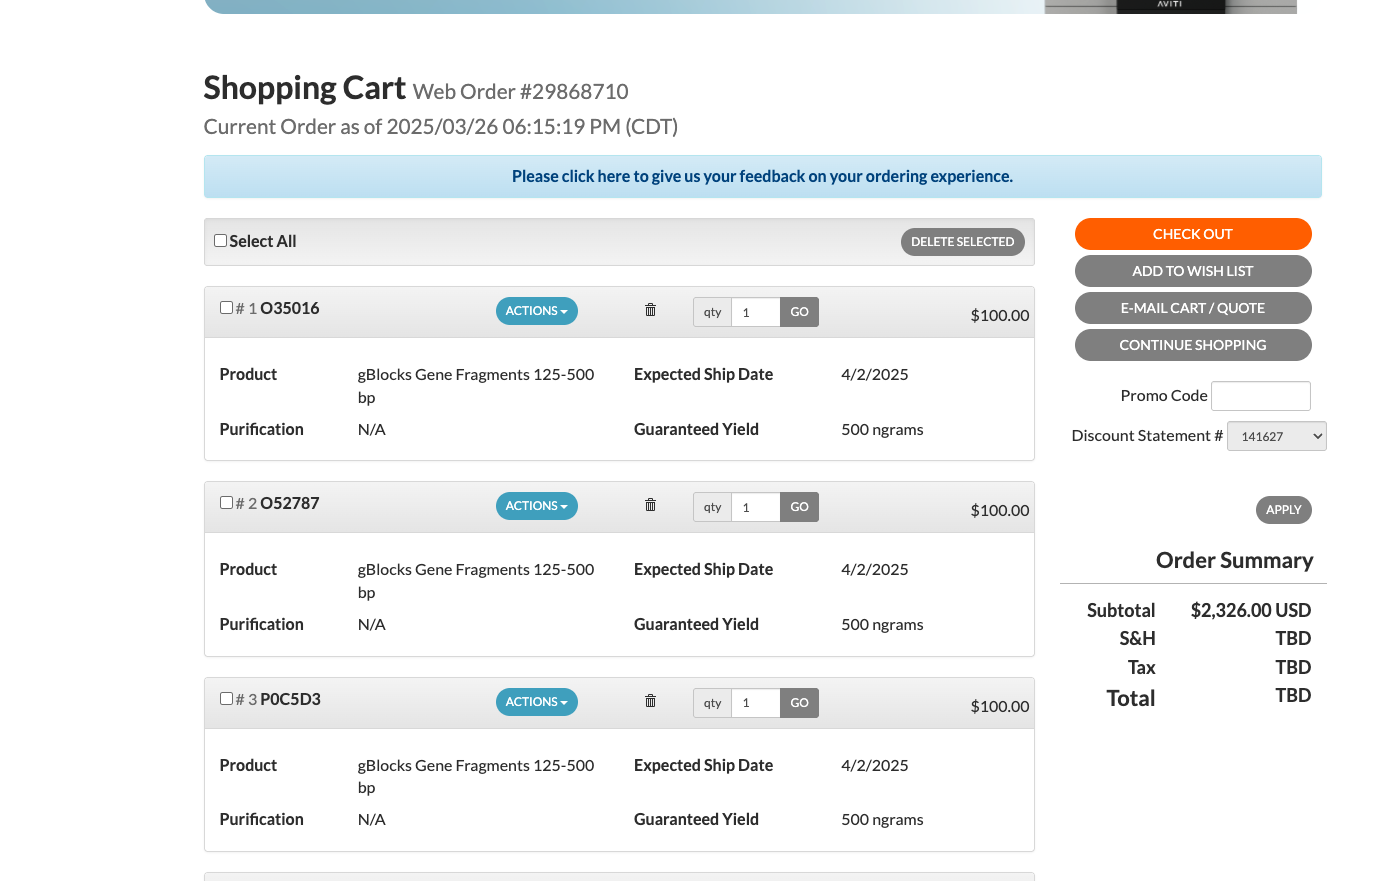
Ordering these without a pool is: $2,326 with IDT

In [ ]:
import pandas as pd
import random
import numpy
import sys
from oligopoolio import *
SEED = 128
random.seed(SEED)
numpy.random.seed(SEED)

min_gc = 0.25
max_gc = 0.65
min_tm = 10
max_tm = 1000
min_segment_length = 90
max_segment_length = 130
max_length = 500

df = protein_all_info.copy()
# NOte you need to add in the reverse primer to the end of the sequence i.e. you add on the sequence that is the end
primer_lower = 'GATCCGGC'.lower()
os.mkdir(label)
output_directory = f'{label}/'

oligo_df = get_oligos(df, 'CodonOptimized', 'Entry', output_directory, 'gaaataattttgtttaactttaagaaggagatatacat', primer_lower, sequence_end='CTCGAGCACCACCACCACCACCACTGA',
                     min_gc=min_gc, max_gc=max_gc, min_tm=min_tm, max_tm=max_tm, min_segment_length=min_segment_length, max_segment_length=max_segment_length,
                     genbank_file="base-pet22b-base-anm.gb", insert_position=5193, simple=True, codon_optimize=False)
oligo_df.to_csv(f'{output_directory}/oligos_simple_{label}.csv', index=False)
